# Day 05：编码器诞生 —— Transformer Encoder 的完整拼图> 🚀 第十一周 · 注意力时代 · 第 5 天前四天，我们学习了注意力的三个核心组件：1. 缩放点积注意力（Q、K、V）2. 多头注意力3. 位置编码今天，我们要把它们组合起来，加上两个关键"配件"（残差连接 + 层归一化），搭建完整的 **Transformer Encoder**。**今天的任务**：1. 理解 Transformer Encoder 的完整结构2. 认识两个关键配件：残差连接 + 层归一化3. 用代码搭建完整的 Encoder---

## 1. 历史剧场：2017 年的"注意力革命"2017 年，Vaswani 等人发表《Attention Is All You Need》，提出了 Transformer：> **抛弃 RNN 和 CNN，只用注意力机制来建模序列。**这个大胆的想法在当时被很多人质疑——没有循环结构，怎么处理序列？答案是：**注意力 + 位置编码 = 不需要循环也能理解序列。**Transformer 的核心创新：- **自注意力（Self-Attention）**：让序列中的每个词都能看到所有其他词- **并行计算**：不像 RNN 那样必须按顺序处理，所有位置同时计算- **残差连接 + 层归一化**：让深层网络训练稳定---

## 2. 生活隐喻：团队会议的决策流程Transformer Encoder 就像一个高效的团队会议：1. **自注意力**：每个人先听所有人的发言，关注与自己相关的部分2. **残差连接**：保留自己的原始想法，不因为听了别人就完全改变3. **层归一化**：统一发言的"音量"，防止某些人声音太大或太小4. **前馈网络**：每个人独立思考，深入分析自己关注的信息5. **再残差 + 再归一化**：保留思考结果，统一输出格式---

<p align="center">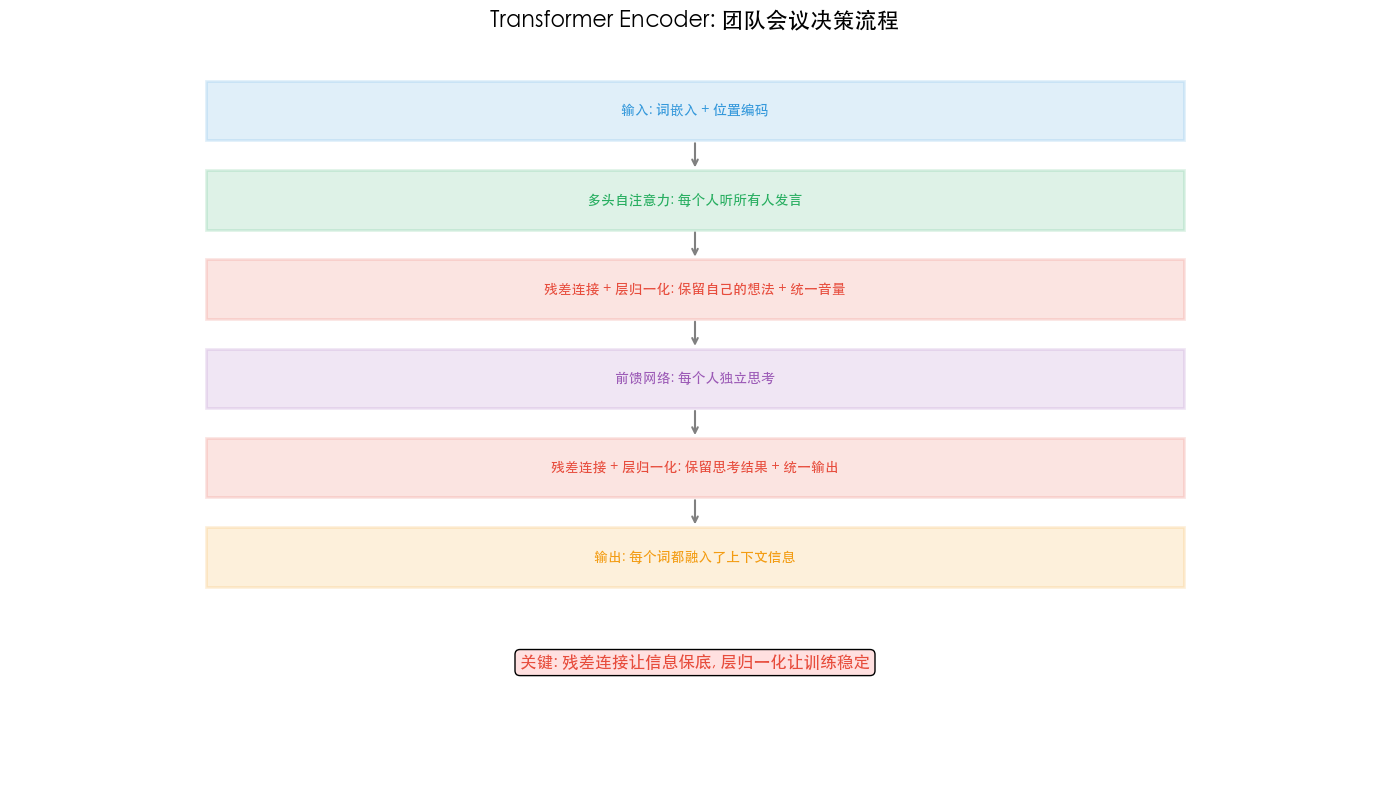</p>*Transformer Encoder 决策流程图*

## 3. 数学直觉：Encoder 的完整结构一个 Encoder 层包含：

输入 x  ↓多头自注意力 + 残差连接 + 层归一化  ↓前馈网络 (FFN) + 残差连接 + 层归一化  ↓输出

### 3.1 自注意力子层$$\text{Sublayer}_1(x) = \text{LayerNorm}(x + \text{MultiHead}(x, x, x))$$- Q = K = V = x（自注意力：用自己查询自己）- 残差连接：$x + \text{MultiHead}(x)$（类似 ResNet！）- 层归一化：稳定训练### 3.2 前馈网络子层$$\text{Sublayer}_2(x) = \text{LayerNorm}(x + \text{FFN}(x))$$- FFN 通常是两层 MLP：$\text{FFN}(x) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$- 内部维度通常是模型维度的 4 倍- 残差连接 + 层归一化---

## 4. 代码实验室：搭建完整 Encoder

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 手写 Transformer Encoder 层

In [ ]:
class TransformerEncoderLayer(nn.Module):    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):        super().__init__()        self.d_model = d_model        self.W_Q = nn.Linear(d_model, d_model)        self.W_K = nn.Linear(d_model, d_model)        self.W_V = nn.Linear(d_model, d_model)        self.W_O = nn.Linear(d_model, d_model)        self.n_heads = n_heads        self.d_k = d_model // n_heads        self.norm1 = nn.LayerNorm(d_model)        self.norm2 = nn.LayerNorm(d_model)        self.ffn = nn.Sequential(            nn.Linear(d_model, d_ff),            nn.ReLU(),            nn.Dropout(dropout),            nn.Linear(d_ff, d_model),            nn.Dropout(dropout)        )        self.dropout = nn.Dropout(dropout)    def multi_head_attention(self, x):        B, S, D = x.shape        Q = self.W_Q(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)        K = self.W_K(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)        V = self.W_V(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)        scores = Q @ K.transpose(-2, -1) / np.sqrt(self.d_k)        attn = F.softmax(scores, dim=-1)        context = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)        return self.W_O(context), attn    def forward(self, x):        attn_out, attn_weights = self.multi_head_attention(x)        x = self.norm1(x + self.dropout(attn_out))        ffn_out = self.ffn(x)        x = self.norm2(x + ffn_out)        return x, attn_weightsclass TransformerEncoder(nn.Module):    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, max_len=100):        super().__init__()        self.embedding = nn.Embedding(vocab_size, d_model)        self.pos_encoding = nn.Parameter(self._positional_encoding(max_len, d_model),                                          requires_grad=False)        self.layers = nn.ModuleList([            TransformerEncoderLayer(d_model, n_heads, d_ff)            for _ in range(n_layers)        ])    def _positional_encoding(self, max_len, d_model):        PE = torch.zeros(max_len, d_model)        position = torch.arange(max_len).unsqueeze(1).float()        div_term = torch.exp(torch.arange(0, d_model, 2).float() *                            -(np.log(10000.0) / d_model))        PE[:, 0::2] = torch.sin(position * div_term)        PE[:, 1::2] = torch.cos(position * div_term)        return PE.unsqueeze(0)    def forward(self, x):        B, S = x.shape        x = self.embedding(x) + self.pos_encoding[:, :S, :]        all_attn = []        for layer in self.layers:            x, attn = layer(x)            all_attn.append(attn)        return x, all_attn

### 4.2 测试 Encoder

In [ ]:
vocab_size = 20d_model = 32n_heads = 4d_ff = 128n_layers = 2encoder = TransformerEncoder(vocab_size, d_model, n_heads, d_ff, n_layers)x = torch.randint(0, vocab_size, (2, 10))output, all_attn = encoder(x)print(f"输入: {x.shape}")print(f"输出: {output.shape}")print(f"注意力层数: {len(all_attn)}")print(f"每层注意力形状: {all_attn[0].shape}")total_params = sum(p.numel() for p in encoder.parameters())print(f"总参数量: {total_params:,}")

### 4.3 可视化 Encoder 的注意力

In [ ]:
fig, axes = plt.subplots(n_layers, n_heads, figsize=(4*n_heads, 3*n_layers))labels = [f'词{i+1}' for i in range(10)]for layer_idx in range(n_layers):    for head_idx in range(n_heads):        ax = axes[layer_idx][head_idx]        attn = all_attn[layer_idx][0, head_idx].detach().numpy()        im = ax.imshow(attn, cmap='YlOrRd', vmin=0)        ax.set_title(f'层{layer_idx+1}-头{head_idx+1}', fontsize=10)        ax.set_xticks(range(10))        ax.set_xticklabels(labels, fontsize=7, rotation=45)        ax.set_yticks(range(10))        ax.set_yticklabels(labels, fontsize=7)plt.suptitle('Transformer Encoder 多头注意力可视化', fontsize=14, y=1.02)plt.tight_layout()plt.show()

---

## 5. Encoder 的关键设计| 组件 | 作用 | 类比 ||---|---|---|| 自注意力 | 让每个词看到所有其他词 | 团队讨论 || 多头 | 同时关注不同关系 | 多个侦探 || 残差连接 | 保留原始信息，防止退化 | ResNet 的近道 || 层归一化 | 稳定训练，加速收敛 | 统一音量 || 前馈网络 | 深入分析关注的信息 | 个人独立思考 || 位置编码 | 提供顺序信息 | 座次牌 |**关键洞察**：Transformer Encoder 的每个组件都有明确的目的，它们组合在一起形成了一个强大的"信息处理流水线"。---

## 今日结语今天我们搭建了完整的 Transformer Encoder：1. **词嵌入 + 位置编码** → 带位置信息的词表示2. **多头自注意力 + 残差 + 归一化** → 每个词看到所有其他词3. **前馈网络 + 残差 + 归一化** → 深入分析关注的信息Encoder 是 Transformer 的"理解"部分——它把输入序列编码成富含上下文信息的表示。下周，我们将学习 Transformer 的"生成"部分——Decoder，以及完整的 Transformer 架构。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 团队会议的决策流程 | Transformer Encoder 层 || 听完别人后保留自己的想法 | 残差连接 x + Attention(x) || 统一发言音量 | 层归一化 LayerNorm || 个人独立思考 | 前馈网络 FFN || 用自己查询自己 | 自注意力 Q=K=V=x |